# NYT Connections Puzzle Solver
## DATA 620 Final Project

Authors: Kevin Havis and Aaliyah John-Harry

## Introduction

The New York Times hosts several puzzle games on its website, but perhaps the most popular is Connections.

Connections is a word game where the player is given sixteen words and must group them into four categories of four words each based on hidden relationships or implicit patterns.

These relationships may be semantic, structural (prefixes/suffixes), or cultural references. The puzzle is intentionally designed to mislead players with plausible but incorrect groupings. In practice, players look for logical groups of four words, progressively eliminating words as they get the groupings correct.

Our goal is to develop a model that can automatically group the sixteen words into their correct categories using a combination of natural language processing (NLP) and network analysis techniques.

### Research Question
Can a combination of semantic embeddings and network-based clustering accurately identify the hidden groupings in NYT Connections puzzles, outperforming baseline methods such as random grouping and simple similarity measures?

### Hypothesis
We expect that combining word embeddings with network-based clustering will outperform both random grouping and simple cosine similarity, approaching human-level performance on historical puzzles.

### Potential Challenges/Concerns

- The primary challenge is the diversity of relationships between words.
    - Simple methods such as cosine similarity may capture semantic meaning but fail to detect structural or contextual patterns.
    - Additionally, the puzzle often intentionally misdirects the player by providing words that can be intuitively grouped but do not fit the predetermined category.
- Categories may rely on cultural knowledge not captured by NLP techniques.
    - Additionally, clustering evaluation is complex due to multiple plausible groupings. 

### Approach

We have several tools we can use to take on this problem.

#### Data

We will use historical NYT Connections puzzles and their solutions from a public GitHub dataset maintained by *Eyefyre* on [GitHub](https://github.com/Eyefyre/NYT-Connections-Answers).


#### Techniques

We must use a combination of techniques to address all potential "angles" of word classification.

- Word Embeddings: Vectorizing the words can give us some initial groupings of similar words by common language 
- Text Processing: Stemming and lemmatization will be used to identify structural relationships.
- Network analysis: Modeling the words as nodes and their connections as edges is a natural approach to this type of "neighbor" clustering

#### Evaluation

Model evaluation for clustering can be challenging; to measure our model's performance, we will compare against the following benchmarks.

- Random Association: Random grouping of words, measured by accuracy
- Simple Word Vector Embeddings: Groups based on semantic similarity.
- LLM Performance: Human-equivalent or better performance
- Human Benchmark: Comparison against known puzzle solutions.

Performance will be measured based on how accurately the model reproduces the correct groupings.

### Roles and Responsibilities

- Aaliyah John-Harry:
    - Text preprocessing
    - Feature engineering
    - Model development
- Kevin Havis:
    - Network construction
    - Graph analysis
    - Clustering methods
- Both:
    - Evaluation
    - Interpretation
    - Presentation

In [21]:
import os
import sys

# Ensure local modules are importable regardless of launch directory
for candidate in [os.getcwd(), os.path.join(os.getcwd(), "project4")]:
    if os.path.isdir(candidate) and candidate not in sys.path:
        sys.path.insert(0, candidate)

import importlib
import random

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# Note - import will take a while as we load all the GloVe embeddings
from data import DataLoader
from embeddings import Embedder, rank_word_combinations


/Users/kevinhav/projects/data_620
['/Users/kevinhav/gensim-data', '/Users/kevinhav/projects/data_620/project4', '/Users/kevinhav/projects/data_620']


In [24]:
loader = DataLoader()
df = loader.df

In [25]:
puzzle_index = 0

raw_puzzle = loader.get_puzzle(puzzle_index)
words = loader.words[puzzle_index]

print(words)

['HAIL', 'RAIN', 'SLEET', 'SNOW', 'BUCKS', 'HEAT', 'JAZZ', 'NETS', 'OPTION', 'RETURN', 'SHIFT', 'TAB', 'KAYAK', 'LEVEL', 'MOM', 'RACECAR']


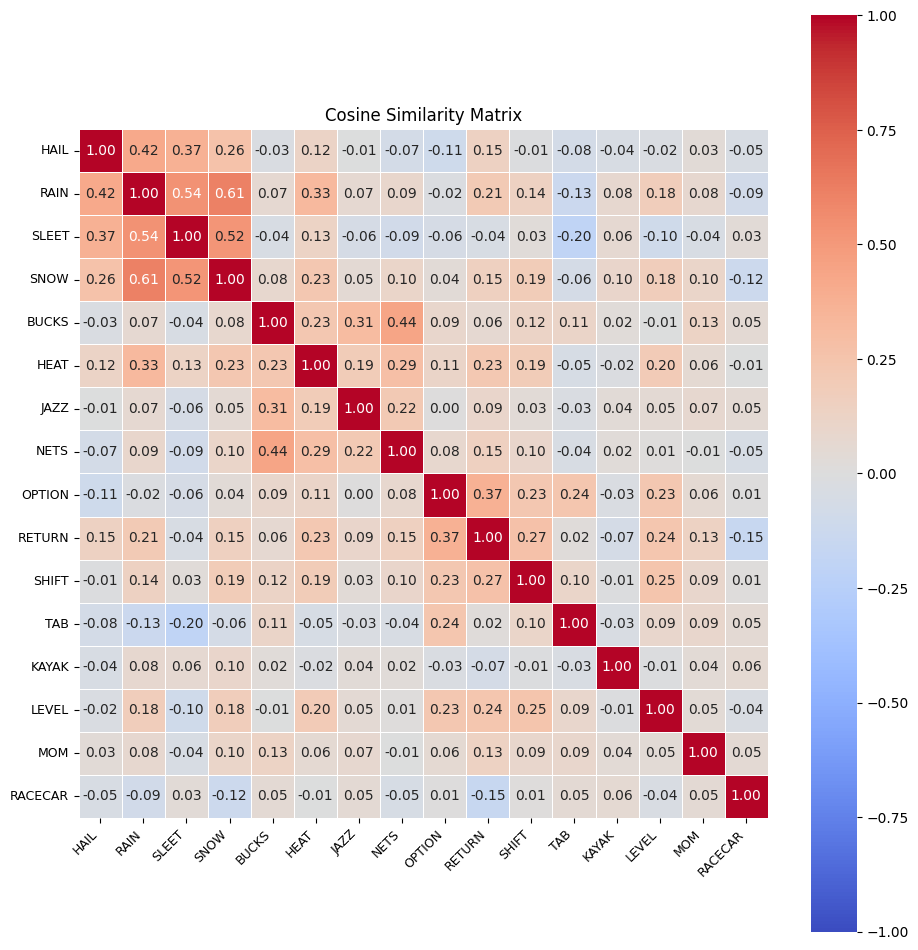

In [26]:
embedder = Embedder(words)

embedder.get_glove_embeddings()

similarity_matrix = embedder.get_cosine_similarity()

fig = embedder.plot_similarity_matrix()

In [27]:
ranked_groups = rank_word_combinations(words, similarity_matrix)

ranked_groups.head(20)

,combo_words,combo_indices,mean_cosine_similarity
0,"(HAIL, RAIN, SLEET, SNOW)","(0, 1, 2, 3)",0.452395
1,"(RAIN, SLEET, SNOW, HEAT)","(1, 2, 3, 5)",0.390996
2,"(RAIN, SLEET, SNOW, SHIFT)","(1, 2, 3, 10)",0.337398
3,"(RAIN, SLEET, SNOW, RETURN)","(1, 2, 3, 9)",0.329706
4,"(HAIL, RAIN, SNOW, HEAT)","(0, 1, 3, 5)",0.327892
5,"(RAIN, SLEET, SNOW, LEVEL)","(1, 2, 3, 13)",0.319314
6,"(HAIL, RAIN, SLEET, HEAT)","(0, 1, 2, 5)",0.317802
7,"(RAIN, SLEET, SNOW, KAYAK)","(1, 2, 3, 12)",0.317405
8,"(RAIN, SLEET, SNOW, MOM)","(1, 2, 3, 14)",0.300440
9,"(HAIL, RAIN, SNOW, RETURN)","(0, 1, 3, 9)",0.299162


In [28]:
def get_true_groups(raw_puzzle):
    true_groups = []

    for answer in raw_puzzle["answers"]:
        true_groups.append(frozenset(answer["members"]))

    return true_groups

In [29]:
true_groups = get_true_groups(raw_puzzle)

ranked_groups["is_true_group"] = ranked_groups["combo_words"].apply(
    lambda x: frozenset(x) in true_groups
)

ranked_groups[ranked_groups["is_true_group"] == True]

,combo_words,combo_indices,mean_cosine_similarity,is_true_group
0,"(HAIL, RAIN, SLEET, SNOW)","(0, 1, 2, 3)",0.452395,True
16,"(BUCKS, HEAT, JAZZ, NETS)","(4, 5, 6, 7)",0.280209,True
80,"(OPTION, RETURN, SHIFT, TAB)","(8, 9, 10, 11)",0.205211,True
1517,"(KAYAK, LEVEL, MOM, RACECAR)","(12, 13, 14, 15)",0.024869,True


In [30]:
ranked_groups["rank"] = ranked_groups.index + 1

In [31]:
ranked_groups[ranked_groups["is_true_group"] == True]

,combo_words,combo_indices,mean_cosine_similarity,is_true_group,rank
0,"(HAIL, RAIN, SLEET, SNOW)","(0, 1, 2, 3)",0.452395,True,1
16,"(BUCKS, HEAT, JAZZ, NETS)","(4, 5, 6, 7)",0.280209,True,17
80,"(OPTION, RETURN, SHIFT, TAB)","(8, 9, 10, 11)",0.205211,True,81
1517,"(KAYAK, LEVEL, MOM, RACECAR)","(12, 13, 14, 15)",0.024869,True,1518


In [32]:
results = []

for puzzle_index in range(len(loader.words)):
    raw_puzzle = loader.get_puzzle(puzzle_index)
    words = loader.words[puzzle_index]

    embedder = Embedder(words)

    embedder.get_glove_embeddings()

    similarity_matrix = embedder.get_cosine_similarity()

    ranked_groups = rank_word_combinations(words, similarity_matrix)

    true_groups = get_true_groups(raw_puzzle)

    ranked_groups["is_true_group"] = ranked_groups["combo_words"].apply(
        lambda x: frozenset(x) in true_groups
    )

    ranked_groups["rank"] = ranked_groups.index + 1

    true_rankings = ranked_groups[ranked_groups["is_true_group"] == True][
        "rank"
    ].tolist()

    results.extend(true_rankings)

In [33]:
average_true_group_rank = np.mean(results)
median_true_group_rank = np.median(results)

best_ranked_true_group = min(results)
worst_ranked_true_group = max(results)

print(f"Average true-group rank: {average_true_group_rank:.2f}")
print(f"Median true-group rank: {median_true_group_rank:.2f}")
print(f"Best-ranked true group: {best_ranked_true_group}")
print(f"Worst-ranked true group: {worst_ranked_true_group}")

Average true-group rank: 647.34
Median true-group rank: 519.00
Best-ranked true group: 1
Worst-ranked true group: 1820


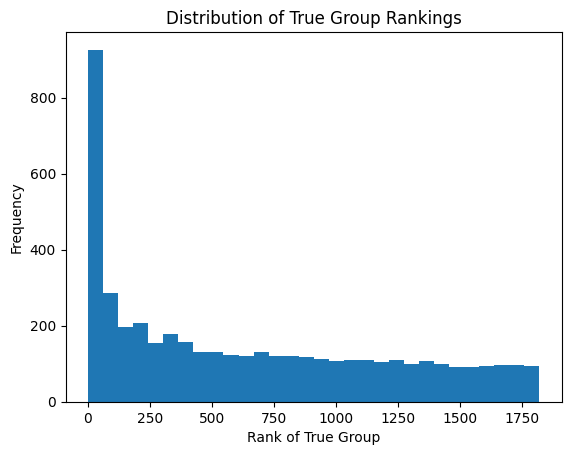

In [34]:
plt.hist(results, bins=30)
plt.xlabel("Rank of True Group")
plt.ylabel("Frequency")
plt.title("Distribution of True Group Rankings")
plt.show()

The distribution of true-group rankings is strongly right-skewed. Many correct categories ranked very highly using cosine similarity, indicating that semantic embeddings effectively capture meaning-based relationships between words.

However, a subset of categories ranked extremely poorly. These low-performing categories were often based on structural or contextual relationships rather than semantic meaning, such as palindromes or keyboard keys.

This demonstrates that embedding-based similarity can serve as a strong baseline for solving NYT Connections puzzles, but semantic similarity alone is insufficient for handling the full range of puzzle patterns used by the game.

## Greedy Cosine Similarity Solver

Having established that cosine similarity rankings capture many true groups, we can now build a greedy solver that attempts to identify all four categories for each puzzle.

The solver works iteratively: at each step it selects the highest-ranked four-word group from the remaining pool of words, removes those words, and repeats until four groups have been identified. The fourth group is determined automatically by the words that remain after three selections.

A puzzle is considered a win if the solver correctly identifies at least three of the four groups.

In [35]:
def solve_puzzle(words, similarity_matrix, true_groups):

    ranked = rank_word_combinations(words, similarity_matrix)

    remaining_indices = set(range(len(words)))
    predicted_groups = []

    for _ in range(3):

        valid = ranked[
            ranked["combo_indices"].apply(
                lambda idxs: set(idxs).issubset(remaining_indices)
            )
        ]

        if valid.empty:
            break

        best_row = valid.iloc[0]
        predicted_groups.append(frozenset(best_row["combo_words"]))
        remaining_indices -= set(best_row["combo_indices"])

    predicted_groups.append(frozenset(words[i] for i in remaining_indices))

    correct = sum(1 for g in predicted_groups if g in true_groups)
    return predicted_groups, correct

In [36]:
solver_results = []

for puzzle_index in range(len(loader.words)):
    raw_puzzle = loader.get_puzzle(puzzle_index)
    words = loader.words[puzzle_index]

    embedder = Embedder(words)
    embedder.get_glove_embeddings()
    similarity_matrix = embedder.get_cosine_similarity()

    true_groups = get_true_groups(raw_puzzle)
    predicted_groups, correct = solve_puzzle(words, similarity_matrix, true_groups)

    solver_results.append(
        {"puzzle_index": puzzle_index, "correct_groups": correct, "win": correct >= 3}
    )

solver_df = pd.DataFrame(solver_results)

IndexError: single positional indexer is out-of-bounds

Wins: 3/50
Win rate: 6.0%
Average correct groups per puzzle: 1.02


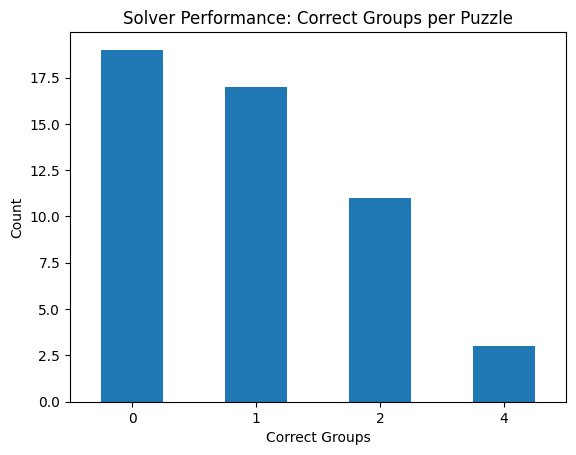

In [ ]:
wins = solver_df["win"].sum()
total = len(solver_df)
win_rate = wins / total

print(f"Wins: {wins}/{total}")
print(f"Win rate: {win_rate:.1%}")
print(f"Average correct groups per puzzle: {solver_df['correct_groups'].mean():.2f}")

solver_df["correct_groups"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Correct Groups")
plt.ylabel("Count")
plt.title("Solver Performance: Correct Groups per Puzzle")
plt.xticks(rotation=0)
plt.show()

## Random Baseline

To contextualize the solver's performance, we establish a random baseline by repeatedly assigning the sixteen words to four groups at random. Each puzzle is evaluated over 100 random trials; the win rate and average correct groups are averaged across trials to produce a stable estimate.

In [ ]:
N_TRIALS = 100
random_results = []

for puzzle_index in range(len(loader.words)):

    words = loader.words[puzzle_index]
    raw_puzzle = loader.get_puzzle(puzzle_index)
    true_groups = get_true_groups(raw_puzzle)

    wins = 0
    total_correct = 0

    for _ in range(N_TRIALS):
        shuffled = words[:]
        random.shuffle(shuffled)
        predicted = [frozenset(shuffled[i:i+4]) for i in range(0, 16, 4)]
        correct = sum(1 for g in predicted if g in true_groups)
        total_correct += correct
        if correct >= 3:
            wins += 1

    random_results.append({
        "puzzle_index": puzzle_index,
        "correct_groups": total_correct / N_TRIALS,
        "win_rate": wins / N_TRIALS
    })

random_df = pd.DataFrame(random_results)

In [ ]:
random_win_rate = random_df["win_rate"].mean()
random_avg_correct = random_df["correct_groups"].mean()

solver_win_rate = solver_df["win"].mean()
solver_avg_correct = solver_df["correct_groups"].mean()

print(f"{"":20} {"Win Rate":>10} {"Avg Correct Groups":>20}")
print(f"{"Random Baseline":20} {random_win_rate:>10.1%} {random_avg_correct:>20.2f}")
print(f"{"Cosine Solver":20} {solver_win_rate:>10.1%} {solver_avg_correct:>20.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["Random", "Cosine Solver"], [random_win_rate, solver_win_rate], color=["gray", "steelblue"])
axes[0].set_ylabel("Win Rate")
axes[0].set_title("Win Rate Comparison")
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

axes[1].bar(["Random", "Cosine Solver"], [random_avg_correct, solver_avg_correct], color=["gray", "steelblue"])
axes[1].set_ylabel("Average Correct Groups")
axes[1].set_title("Average Correct Groups Comparison")
axes[1].set_ylim(0, 4)

fig.tight_layout()
plt.show()

## Network Graph Approach

The cosine similarity matrix has a natural graph interpretation: each word is a node, and every pair of words is connected by an edge weighted by their cosine similarity. Words belonging to the same category should form dense, tightly-connected subgraphs, while cross-category connections should be weaker or absent.

Applying a similarity threshold to prune low-weight edges makes the community structure visible. Community detection algorithms—such as the Louvain method or networkx's greedy modularity communities—can then partition the graph into groups that may correspond to the puzzle's four categories.

In [ ]:
NYT_COLORS = {0: "#F9DF6D", 1: "#A0C35A", 2: "#B0C4EF", 3: "#BA81C5"}

puzzle_index = 0

raw_puzzle = loader.get_puzzle(puzzle_index)
words = loader.words[puzzle_index]

embedder = Embedder(words)
embedder.get_glove_embeddings()
similarity_matrix = embedder.get_cosine_similarity()

word_color = {}
for answer in raw_puzzle["answers"]:
    for word in answer["members"]:
        word_color[word] = NYT_COLORS[answer["level"]]

G = nx.Graph()
G.add_nodes_from(words)

threshold = 0.3

for i in range(len(words)):
    for j in range(i + 1, len(words)):
        weight = float(similarity_matrix[i, j])
        if weight > threshold:
            G.add_edge(words[i], words[j], weight=weight)

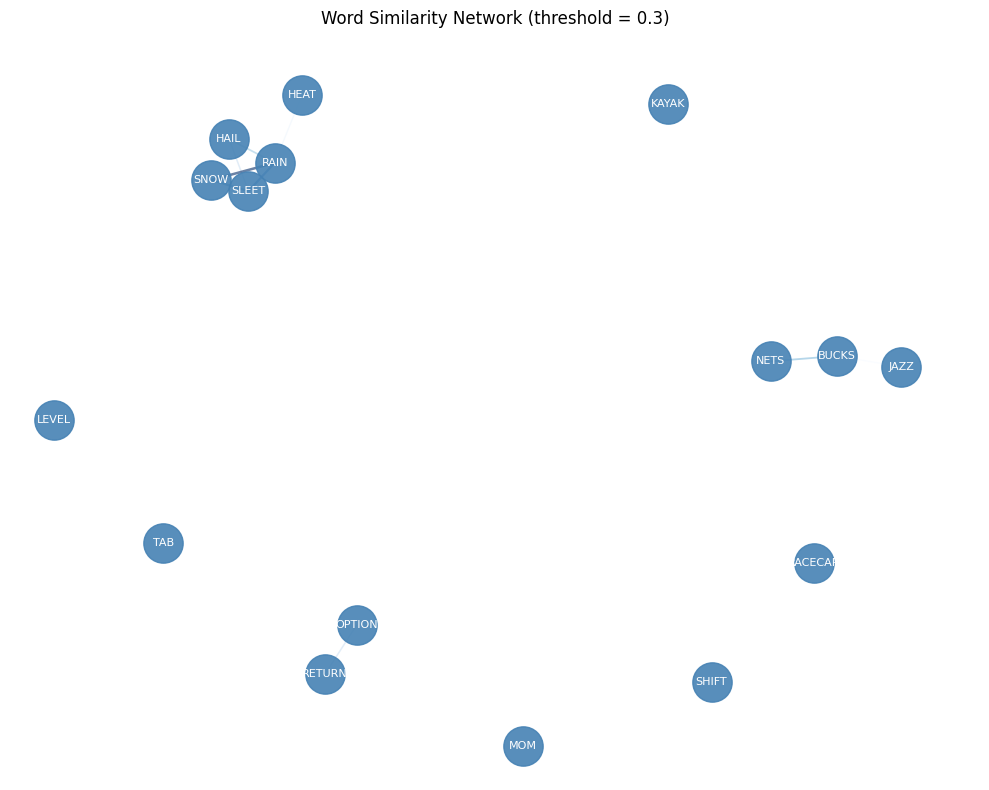

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

pos = nx.spring_layout(G, seed=42)
node_colors = [word_color[w] for w in G.nodes()]
edge_weights = [G[u][v]["weight"] for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=800, node_color=node_colors, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_color="black", ax=ax)
nx.draw_networkx_edges(
    G,
    pos,
    width=[w * 3 for w in edge_weights],
    alpha=0.6,
    edge_color=edge_weights,
    edge_cmap=plt.cm.Greys,
    ax=ax,
)

legend_handles = [
    Patch(facecolor=NYT_COLORS[answer["level"]], label=answer["group"])
    for answer in raw_puzzle["answers"]
]
ax.legend(handles=legend_handles, loc="upper left", framealpha=0.9)

ax.set_title(f"Word Similarity Network (threshold = {threshold})")
ax.axis("off")
fig.tight_layout()
plt.show()

The network graph reveals clusters of semantically related words that emerge naturally from the cosine similarity structure. Words within the same true category tend to form visible communities, connected by strong edges, while cross-category edges are weaker or absent entirely.

This representation opens the door to community detection as a grouping strategy. Rather than greedily selecting the top-ranked combination, a community detection pass over the graph would identify all four groups simultaneously—potentially capturing categories that are individually less salient but collectively well-separated. The approach is also extensible: edges could incorporate multiple similarity signals beyond cosine similarity, such as structural or phonetic features, making the graph a natural integration point for the combined embedding-plus-network strategy described in our original hypothesis.